<a href="https://colab.research.google.com/github/introvet7/CHMP/blob/main/%D0%9A%D0%B8%D1%8F%D1%88%D0%BA%D0%BE_LR_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Кияшко Ілля ФІТ 3-8
ФІТ 3-8, КСВД ЛР-4


## Завдання 1. Аналіз датасету відвідуваності музеїв

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Museum_Visitors.csv')


print("\nПерші 5 рядків датасету:")
display(df.head())

Реальні назви колонок у файлі: ['Month', 'America Tropical Interpretive Center', 'Avila Adobe', 'Chinese American Museum', 'Gateway to Nature Center', 'Firehouse Museum', 'Hellman Quon', 'IAMLA', 'Pico House ', 'Visitor Center/ El Tranquilo Gallery', 'Museum of Social Justice', 'Biscailuz Gallery/ PK Outdoor Exhibit']

Перші 5 рядків датасету:


,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
0,01/01/2014 12:00:00 AM,6602,24778,1581,NaN,4486,0.0,NaN,2204.0,2961.0,NaN,NaN
1,02/01/2014 12:00:00 AM,5029,18976,1785,NaN,4172,0.0,NaN,1330.0,2276.0,NaN,NaN
2,03/01/2014 12:00:00 AM,8129,25231,3229,NaN,7082,70.0,NaN,4320.0,3116.0,NaN,NaN
3,04/01/2014 12:00:00 AM,2824,26989,2129,NaN,6756,250.0,NaN,3277.0,2808.0,NaN,NaN
4,05/01/2014 12:00:00 AM,10694,36883,3676,NaN,10858,135.0,NaN,4122.0,3987.0,NaN,NaN


In [ ]:
# 2. Попередній аналіз даних
print("Розмір датасету:", df.shape)
print("\nТипи даних:\n", df.dtypes)
print("\nКількість пропусків:\n", df.isnull().sum())

# 3. Перевірка на дублікати
duplicates = df.duplicated().sum()
print(f"\nКількість дублікатів: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Розмір таблиці після видалення дублікатів:", df.shape)

# 1. Забираємо випадкові пробіли з назв колонок
df.columns = df.columns.str.strip()

# 2. Перейменовуємо колонку 'Month' на 'Date', щоб весь подальший код працював
df.rename(columns={'Month': 'Date'}, inplace=True)

# 3. Перетворюємо текст на формат справжньої дати
df['Date'] = pd.to_datetime(df['Date'])

# Додамо колонки для зручної роботи з роками та місяцями
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

# 4. Про які роки містить інформацію датасет
years = df['Year'].unique()
print(f"\nДатасет містить інформацію про такі роки: {sorted(years)}")

Розмір датасету: (85, 12)

Типи даних:
 Month                                     object
America Tropical Interpretive Center       int64
Avila Adobe                                int64
Chinese American Museum                    int64
Gateway to Nature Center                 float64
Firehouse Museum                           int64
Hellman Quon                             float64
IAMLA                                    float64
Pico House                               float64
Visitor Center/ El Tranquilo Gallery     float64
Museum of Social Justice                 float64
Biscailuz Gallery/ PK Outdoor Exhibit    float64
dtype: object

Кількість пропусків:
 Month                                     0
America Tropical Interpretive Center      0
Avila Adobe                               0
Chinese American Museum                   0
Gateway to Nature Center                 53
Firehouse Museum                          0
Hellman Quon                             59
IAMLA                      

/tmp/ipykernel_281/3520357785.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
# 5. Змінити назви стовпців
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# Список основних музеїв для аналізу
museums = ['avila_adobe', 'firehouse_museum', 'chinese_american_museum', 'america_tropical_interpretive_center']

# 6. Середня кількість відвідувачів для кожного музею
print("Середня кількість відвідувачів за весь період:")
print(df[museums].mean().round(2))

# 7. Мінімальна та максимальна кількість відвідувачів за 2018 рік
print("\nМінімум та максимум відвідувачів за 2018 рік:")
df_2018 = df[df['year'] == 2018]
for museum in museums:
    print(f"{museum}: Мін = {df_2018[museum].min()}, Макс = {df_2018[museum].max()}")

# 8. Місяці з найвищою і найнижчою кількістю серед усіх музеїв (2015 рік)
df_2015 = df[df['year'] == 2015].copy()
df_2015['total_visitors'] = df_2015[museums].sum(axis=1)

max_month = df_2015.loc[df_2015['total_visitors'].idxmax(), 'month_name']
min_month = df_2015.loc[df_2015['total_visitors'].idxmin(), 'month_name']
print(f"\n2015 рік - Найбільше відвідувачів: {max_month}, Найменше: {min_month}")

# 9. Порівняння Avila Adobe у літні і зимові місяці 2018 року
summer_months = [6, 7, 8]
winter_months = [12, 1, 2]

summer_visitors = df_2018[df_2018['month'].isin(summer_months)]['avila_adobe'].sum()
winter_visitors = df_2018[df_2018['month'].isin(winter_months)]['avila_adobe'].sum()

print(f"\nAvila Adobe (2018): Літо = {summer_visitors}, Зима = {winter_visitors}")

# 10. Кореляція між відвідувачами у 2016 році (без дати)
df_2016 = df[df['year'] == 2016]
corr_2016 = df_2016[museums].corr()
print("\nКореляція між музеями у 2016 році:")
display(corr_2016)

Середня кількість відвідувачів за весь період:
avila_adobe                             19904.95
firehouse_museum                         5286.78
chinese_american_museum                  2359.12
america_tropical_interpretive_center     5637.69
dtype: float64

Мінімум та максимум відвідувачів за 2018 рік:
avila_adobe: Мін = 14718, Макс = 25173
firehouse_museum: Мін = 3306, Макс = 8013
chinese_american_museum: Мін = 2078, Макс = 4960
america_tropical_interpretive_center: Мін = 3180, Макс = 5837

2015 рік - Найбільше відвідувачів: May, Найменше: February

Avila Adobe (2018): Літо = 66122, Зима = 48705

Кореляція між музеями у 2016 році:


,avila_adobe,firehouse_museum,chinese_american_museum,america_tropical_interpretive_center
avila_adobe,1.000000,0.737200,0.089054,0.436561
firehouse_museum,0.737200,1.000000,0.553935,0.247389
chinese_american_museum,0.089054,0.553935,1.000000,0.443800
america_tropical_interpretive_center,0.436561,0.247389,0.443800,1.000000


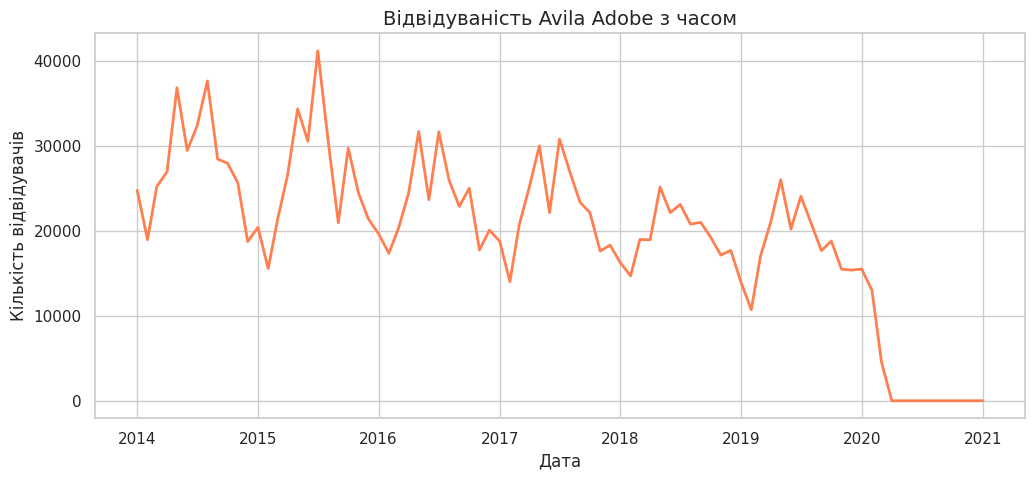

/tmp/ipykernel_281/3778037875.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='chinese_american_museum', palette='Set3')


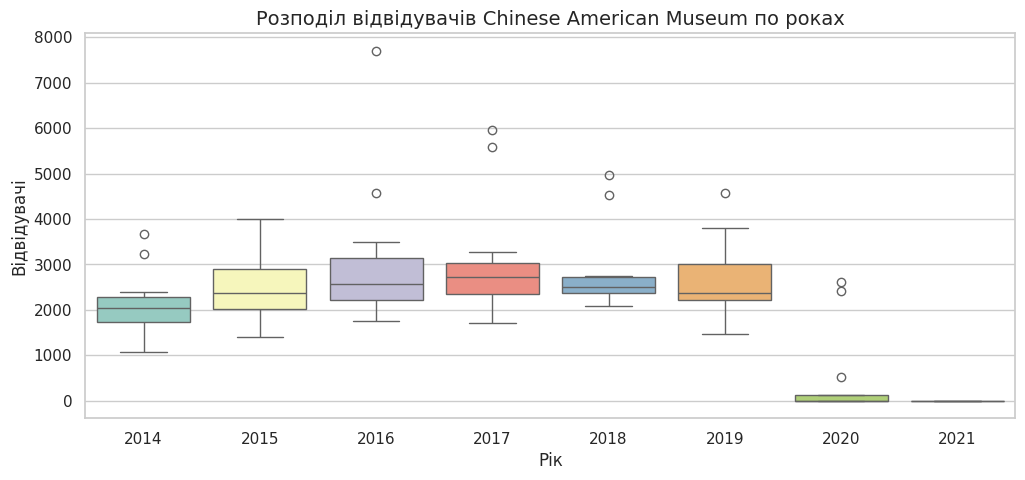

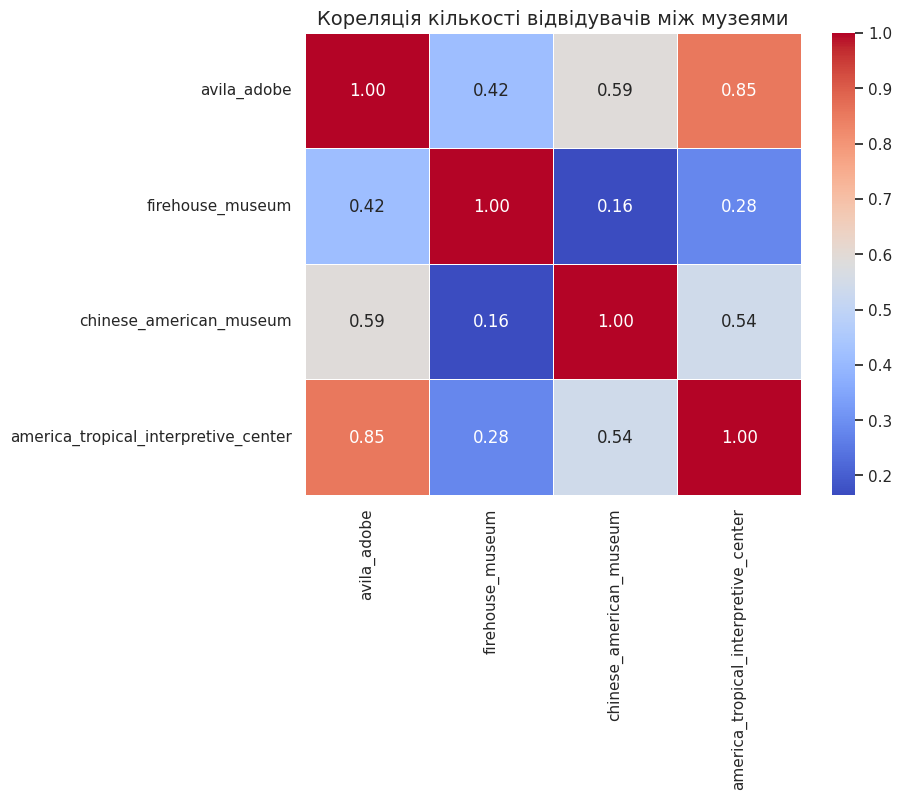

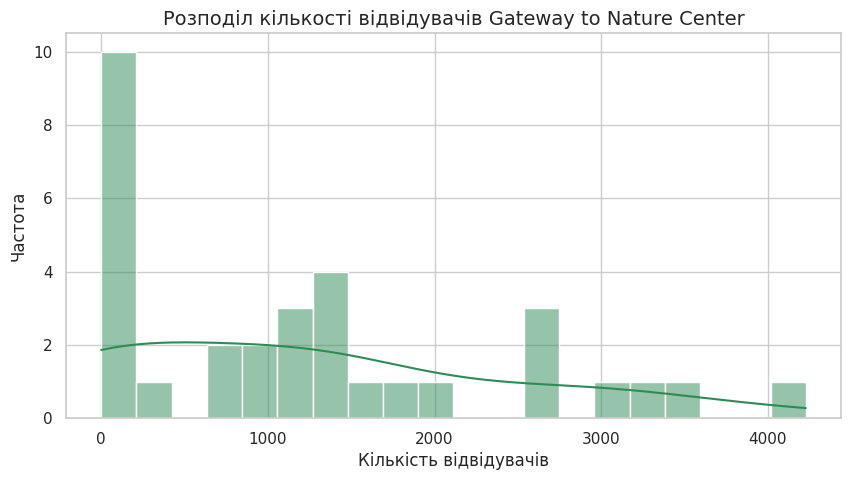

/tmp/ipykernel_281/3778037875.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_visitors.index, y=avg_visitors.values, palette='viridis')


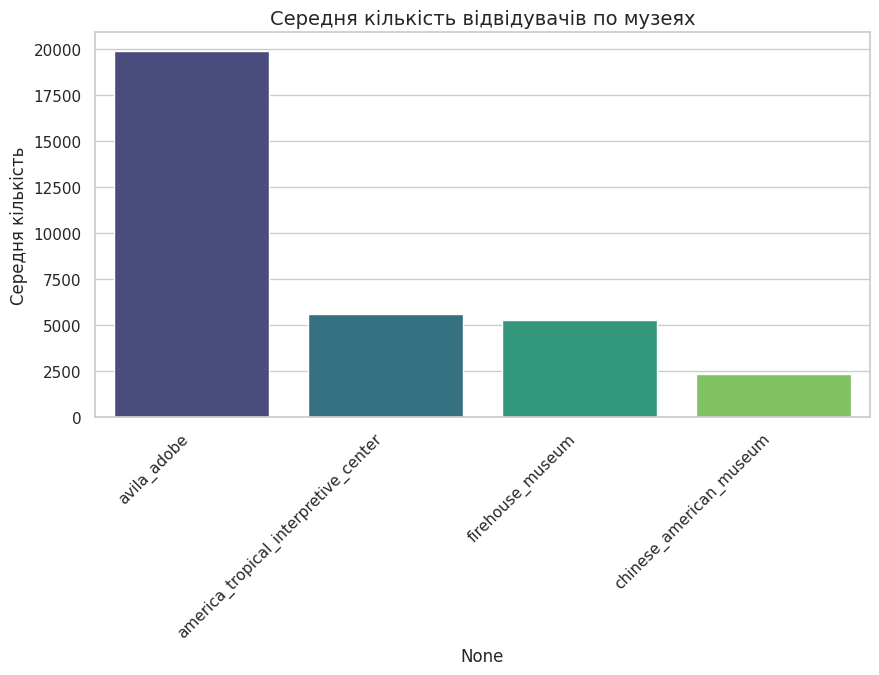

In [ ]:
# Налаштування стилю
sns.set_theme(style="whitegrid")

# 1. Лінійний графік (відвідуваність Avila Adobe з часом)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='date', y='avila_adobe', color='coral', linewidth=2)
plt.title('Відвідуваність Avila Adobe з часом', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Кількість відвідувачів')
plt.show()

# 2. Boxplot (розподіл відвідувачів Chinese American Museum по роках)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='year', y='chinese_american_museum', palette='Set3')
plt.title('Розподіл відвідувачів Chinese American Museum по роках', fontsize=14)
plt.xlabel('Рік')
plt.ylabel('Відвідувачі')
plt.show()

# 3. Heatmap (кореляція між музеями, як просила викладачка - числовий датафрейм)
plt.figure(figsize=(8, 6))
corr_matrix = df[museums].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Кореляція кількості відвідувачів між музеями', fontsize=14)
plt.show()

# 4. Histogram (розподіл Gateway to Nature Center)
if 'gateway_to_nature_center' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df['gateway_to_nature_center'], bins=20, kde=True, color='seagreen')
    plt.title('Розподіл кількості відвідувачів Gateway to Nature Center', fontsize=14)
    plt.xlabel('Кількість відвідувачів')
    plt.ylabel('Частота')
    plt.show()
else:
    print("\nСтовпець 'gateway_to_nature_center' відсутній у поточному датасеті.")

# 5. Barplot (середня кількість відвідувачів по музеях за всі роки)
plt.figure(figsize=(10, 5))
avg_visitors = df[museums].mean().sort_values(ascending=False)
sns.barplot(x=avg_visitors.index, y=avg_visitors.values, palette='viridis')
plt.title('Середня кількість відвідувачів по музеях', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Середня кількість')
plt.show()

## Завдання з лекції: Датасет "Пінгвіни"
Побудова 5 унікальних графіків за допомогою Seaborn.

Перші рядки датасету Пінгвінів:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


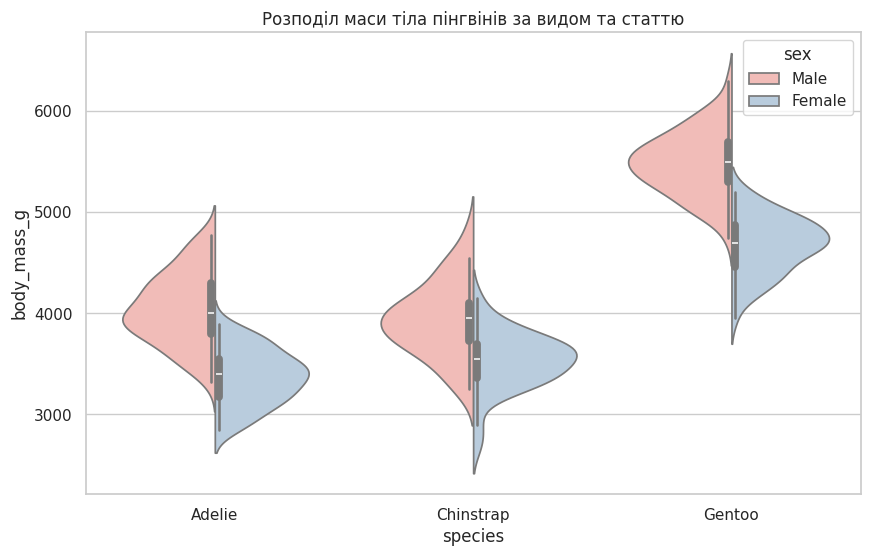

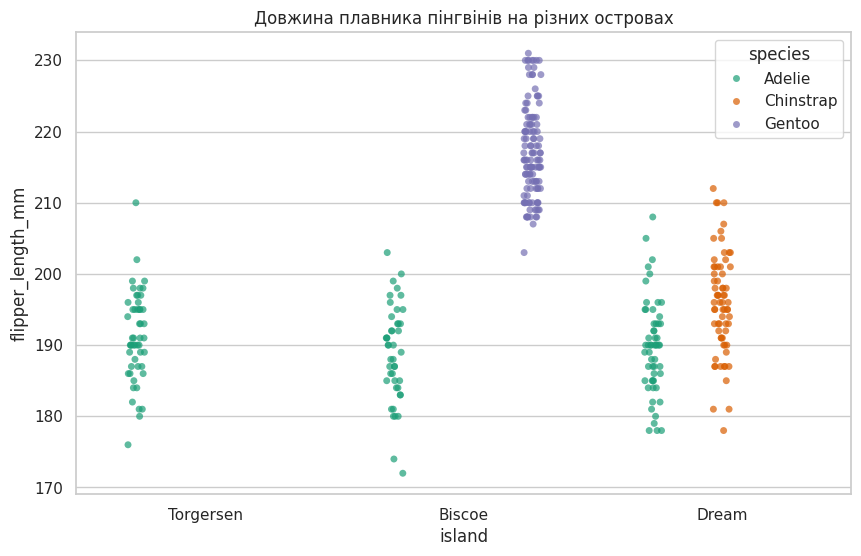

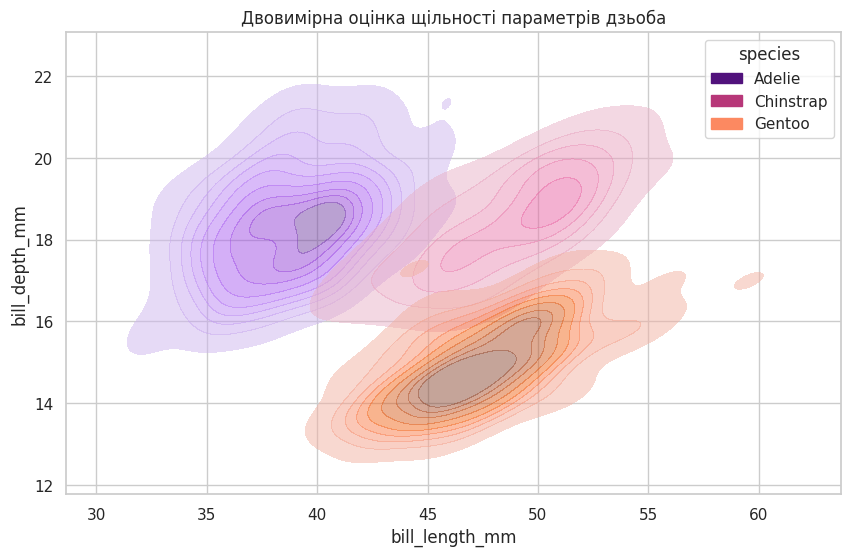

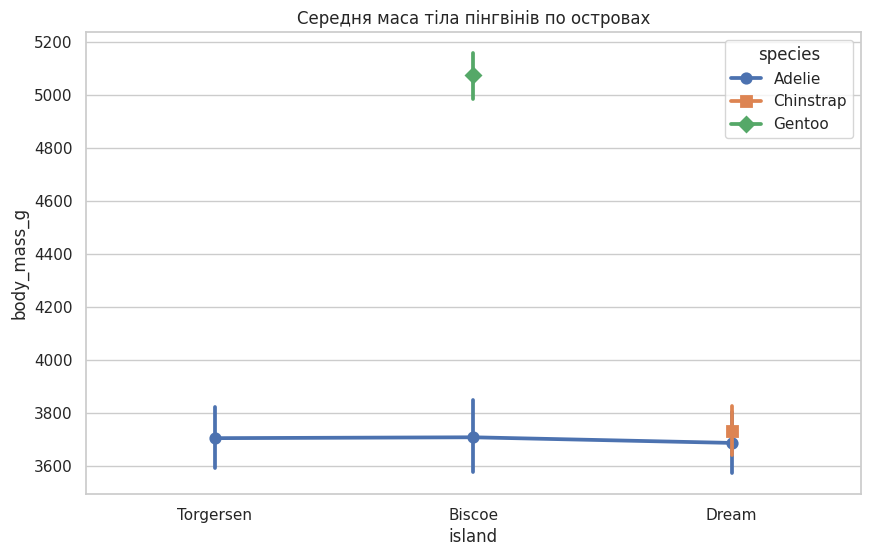

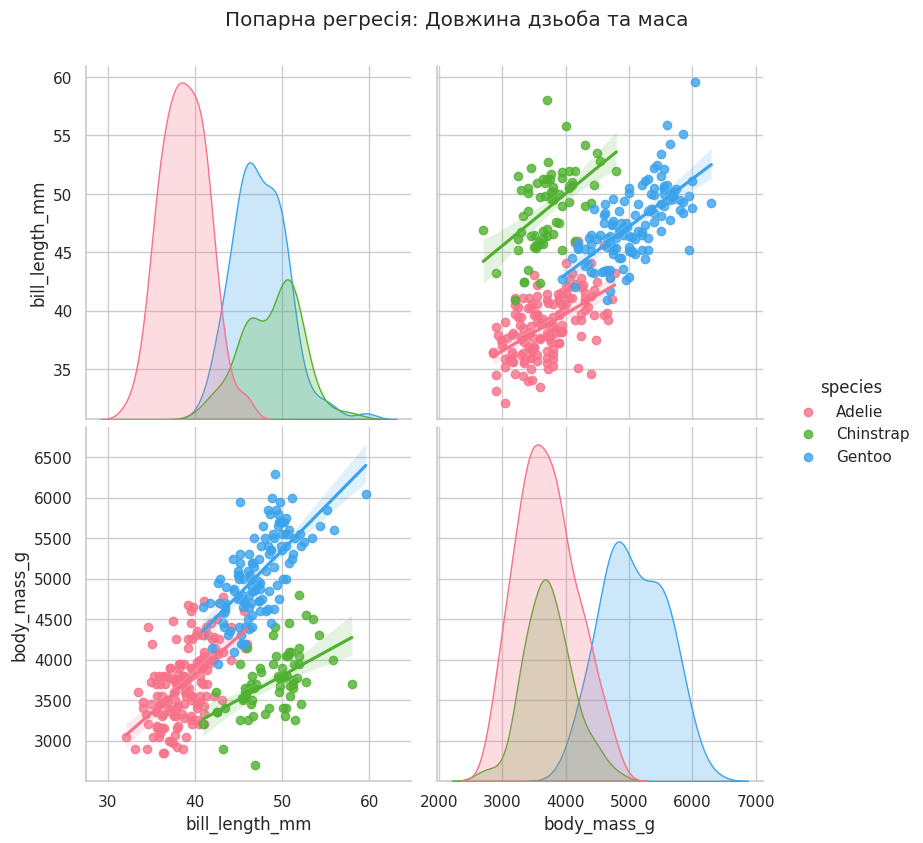

In [ ]:
# Завантажуємо вбудований датасет
penguins = sns.load_dataset("penguins")
print("Перші рядки датасету Пінгвінів:")
display(penguins.head())

# Графік 1: Violinplot (розподіл маси тіла за статтю та видом)
plt.figure(figsize=(10, 6))
sns.violinplot(data=penguins, x='species', y='body_mass_g', hue='sex', split=True, palette='Pastel1')
plt.title('Розподіл маси тіла пінгвінів за видом та статтю')
plt.show()

# Графік 2: Stripplot (Точковий розподіл довжини плавника по островах)
plt.figure(figsize=(10, 6))
sns.stripplot(data=penguins, x='island', y='flipper_length_mm', hue='species', dodge=True, palette='Dark2', alpha=0.7)
plt.title('Довжина плавника пінгвінів на різних островах')
plt.show()

# Графік 3: KDE Plot (Двовимірна густина - довжина vs глибина дзьоба)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='species', fill=True, alpha=0.5, palette='magma')
plt.title('Двовимірна оцінка щільності параметрів дзьоба')
plt.show()

# Графік 4: Pointplot (Оцінка середньої маси тіла з довірчими інтервалами)
plt.figure(figsize=(10, 6))
sns.pointplot(data=penguins, x='island', y='body_mass_g', hue='species', markers=['o', 's', 'D'], palette='deep')
plt.title('Середня маса тіла пінгвінів по островах')
plt.show()

# Графік 5: Pairplot (Спрощений попарний зв'язок параметрів з регресійною лінією)
# Використовуємо kind="reg" для додавання ліній тренду (чого точно не було в стандартному огляді)
sns.pairplot(penguins, vars=['bill_length_mm', 'body_mass_g'], hue='species', kind='reg', palette='husl', height=4)
plt.suptitle('Попарна регресія: Довжина дзьоба та маса', y=1.05)
plt.show()

## Висновки

1. **Попередній аналіз**: Було завантажено та очищено датасет відвідуваності музеїв. Дані переведено до зручного формату (опрацьовано колонки з датами, приведено назви колонок до snake_case).
2. **Аналіз відвідуваності**: Найпопулярнішим музеєм в середньому за всі роки є *Avila Adobe*. Аналіз літніх та зимових місяців показав сезонність відвідуваності.
3. **Кореляція**: Кореляційна матриця (Heatmap) показала, що деякі музеї мають позитивну залежність у відвідуваності, проте високої кореляції (вище 0.9, щоб видаляти змінні згідно з лекційним матеріалом) не виявлено.
4. **Робота з бібліотекою Seaborn**: Було застосовано розширені можливості Seaborn на датасеті `penguins`. Побудовано графіки розподілу (Violinplot), точкові діаграми з розділенням (Stripplot), оцінки щільності (KDE) та попарні регресії (Pairplot), які наочно демонструють відмінності фізичних параметрів різних видів пінгвінів.
